## This notebook presents and analyses the data chosen for the project

<p>
Basically the data consists of 21 files of 1 hour recordings from an amazon forest in Peru. The annotations file cuts the recordings into pieces bouding by start/end and freq top/bottom of a particular bird sound.
</p>

In [6]:
data_path = "data/soundscape_recordings_amazon/"

### Loading the annotations

In [ ]:
import pandas as pd

annotations = pd.read_csv(data_path + "annotations.csv", sep=",")

annotations = annotations[ annotations['Species eBird Code'] != '????' ] # we're taking only known classes

annotations.head(10)

,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species eBird Code
0,PER_001_S01_20190116_100007Z.flac,539.0,541.4,1250,2468,blfant1
1,PER_001_S01_20190116_100007Z.flac,520.5,644.6,961,2884,grasal3
2,PER_001_S01_20190116_100007Z.flac,596.9,598.8,1437,2375,greant1
3,PER_001_S01_20190116_100007Z.flac,655.0,656.8,812,1593,undtin1
4,PER_001_S01_20190116_100007Z.flac,466.3,468.2,552,2658,butwoo1
5,PER_001_S01_20190116_100007Z.flac,502.4,504.6,1346,2571,blfant1
6,PER_001_S01_20190116_100007Z.flac,508.9,511.1,775,2408,butwoo1
9,PER_001_S01_20190116_100007Z.flac,426.1,429.7,1459,2221,blfant1
10,PER_001_S01_20190116_100007Z.flac,431.6,435.9,1459,2416,grasal3
11,PER_001_S01_20190116_100007Z.flac,440.7,444.5,1239,2423,grasal3


In [23]:
annotations['duration_s'] = annotations['End Time (s)'] - annotations['Start Time (s)']
annotations['bandwidth_hz'] = annotations['High Freq (Hz)'] - annotations['Low Freq (Hz)']

print(f"\nOverall:")
print(f"rows: {len(annotations)}")
print(f"unique classes: {annotations['Species eBird Code'].nunique()}")
print(f"total duration: {annotations['duration_s'].sum()/3600:.2f} h")
print(f"low freq range: {annotations['Low Freq (Hz)'].min():.0f}–{annotations['Low Freq (Hz)'].max():.0f} Hz")
print(f"high freq range: {annotations['High Freq (Hz)'].min():.0f}–{annotations['High Freq (Hz)'].max():.0f} Hz")
print(f"bandwidth median(IQR): {annotations['bandwidth_hz'].median():.0f} "
      f"({annotations['bandwidth_hz'].quantile(0.25):.0f}–{annotations['bandwidth_hz'].quantile(0.75):.0f}) Hz")



Overall:
rows: 14798
unique classes: 132
total duration: 35.32 h
low freq range: 0–8273 Hz
high freq range: 263–14884 Hz
bandwidth median(IQR): 1259 (809–1904) Hz


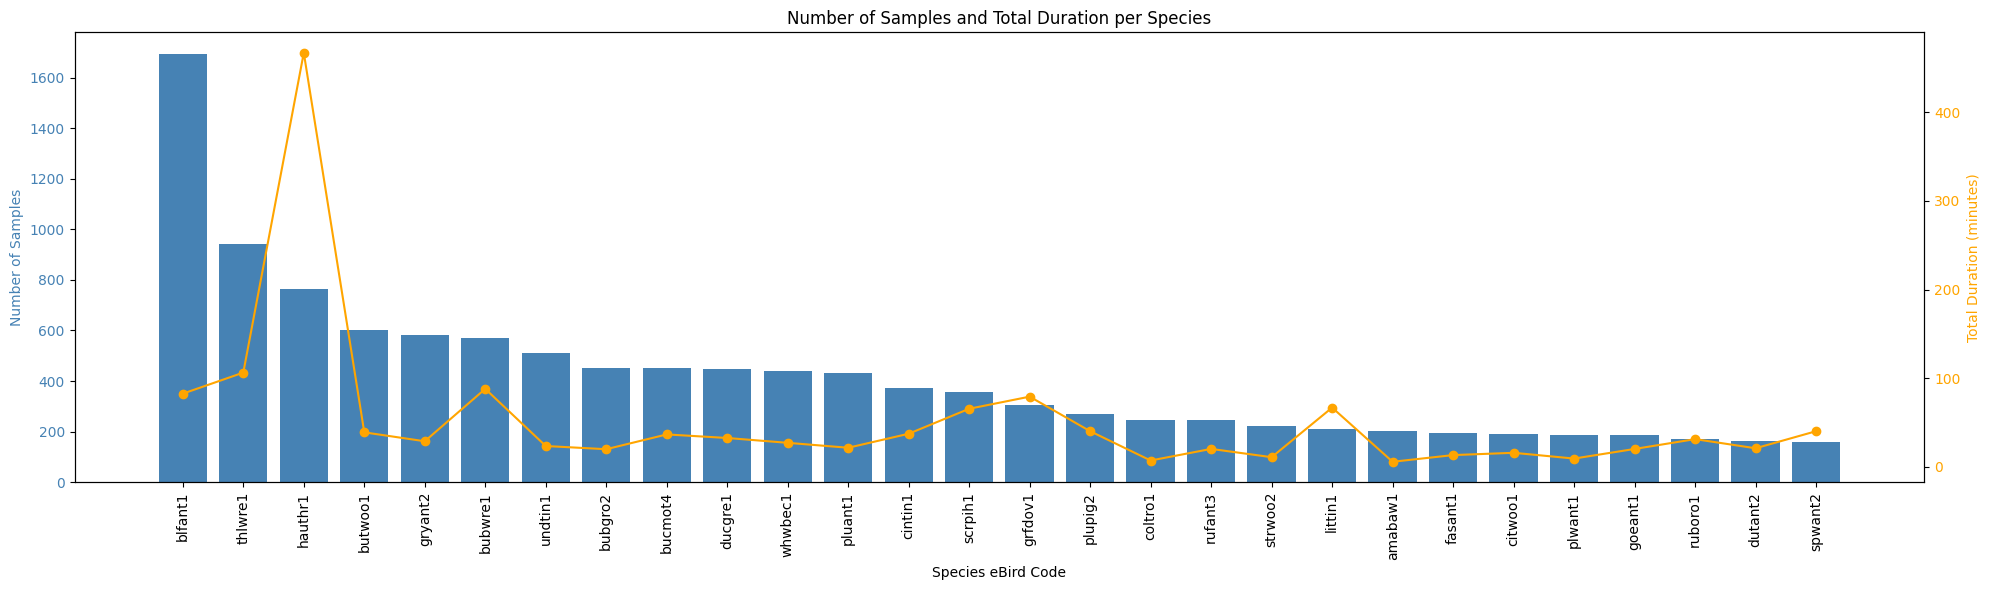

Length of data: 28


In [50]:
%matplotlib inline
import matplotlib.pyplot as plt

# Calculate per-class stats
stats = annotations.groupby('Species eBird Code').agg(
    num_samples=('Species eBird Code', 'count'),
    total_duration_s=('End Time (s)', lambda x: (x - annotations.loc[x.index, 'Start Time (s)']).sum())
).sort_values('num_samples', ascending=False)

stats = stats[stats['num_samples'] > 150]

fig, ax1 = plt.subplots(figsize=(20, 6))

bars = ax1.bar(stats.index, stats['num_samples'], color='steelblue', label='Number of Samples')
ax1.set_xlabel('Species eBird Code')
ax1.set_ylabel('Number of Samples', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(stats.index, stats['total_duration_s'] / 60, color='orange', marker='o', label='Total Duration (minutes)')
ax2.set_ylabel('Total Duration (minutes)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Number of Samples and Total Duration per Species')
fig.tight_layout()
plt.show()

print(f"Length of data: {len(stats)}")